# 06 — MDP: State-Dependent Optimal Policy
**Phase 6: Markov Decision Process via Value Iteration**

The grid search (Phase 5) found the best *static* order-up-to level: S\*=33.  
But S\*=33 ignores the *composition* of inventory — it orders the same whether
the shelf is full of sandwiches expiring today or sandwiches that are fresh.

The MDP finds a **state-dependent** policy: π\*(E0, E1, E2, A1) = optimal order quantity  
that adapts to the current age structure and pipeline.

**Computational approach:** Value iteration with C extension if available (~5s total),  
otherwise pure NumPy fallback (~3–4 min total). Both produce identical results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, time, ctypes, subprocess, tempfile, shutil

DATA_DIR = "../data/processed"
FIG_DIR  = "../outputs/figures"
TBL_DIR  = "../outputs/tables"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TBL_DIR, exist_ok=True)

# ── Economics & system parameters ──
SELL_PRICE, UNIT_COST, SALVAGE = 4.00, 1.50, 0.00
cu = SELL_PRICE - UNIT_COST   # $2.50 underage
co = UNIT_COST - SALVAGE      # $1.50 overage
P_LEAD_1 = 0.8
GAMMA = 0.99                  # discount factor
CAP = 35                      # max inventory position (state space bound)
N_RUNS = 1000
T = 364

print(f"cu=${cu:.2f}, co=${co:.2f}, gamma={GAMMA}, cap={CAP}")

cu=$2.50, co=$1.50, gamma=0.99, cap=35


## 1. Load demand model

In [2]:
P_df = pd.read_csv(os.path.join(DATA_DIR, "sandwich_P_of_D.csv"))
demand_values = P_df["Demand_D"].to_numpy().astype(np.int32)
demand_probs  = P_df["P_smoothed"].to_numpy().astype(np.float64)
n_demands = len(demand_values)

print(f"Demand support: {demand_values.min()}-{demand_values.max()} ({n_demands} values)")
print(f"Mean demand: {(demand_values * demand_probs).sum():.2f}")

Demand support: 0-25 (26 values)
Mean demand: 9.20


## 2. MDP Formulation

**State:** (E0, E1, E2, A1) observed *after* pipeline arrivals, *before* ordering.  
- E0 = units expiring today, E1 = tomorrow, E2 = day after  
- A1 = pipeline units arriving tomorrow  
- A2 = 0 at decision time (arrivals already shifted), so **4 state variables, not 5**  
- Constraint: E0 + E1 + E2 + A1 <= CAP  

**Action:** Order quantity q in {0, 1, ..., CAP - inventory position}  

**Transition (given action q, demand D, lead time L):**  
1. Order enters pipeline: if L=1, new A1 gets q; if L=2, new A2 gets q  
2. FIFO consumption: eat from E0 (oldest), then E1, then E2  
3. Waste: any remaining E0 after demand expires  
4. Aging: E0 <- E1, E1 <- E2, E2 <- 0  
5. Next-day arrivals: A1 arrives into E2, pipeline shifts, A2 -> A1, A2 <- 0  

**Cost:** cu * unmet + co * waste (per day)  

**Objective:** Minimize expected discounted total cost, infinite horizon  

**State space:** 82,251 reachable states

## 3. Build value iteration engine

We attempt to compile a C extension for speed (~0.1s/sweep).  
If no C compiler is found (common on Windows), we fall back to  
an optimized NumPy implementation (~10s/sweep). Both give identical results.

In [3]:
# ══════════════════════════════════════════════════════════════
# OPTION A: C extension (fast — ~0.1s per sweep)
# ══════════════════════════════════════════════════════════════

C_CODE = r"""
#include <math.h>
void vi_sweep(
    double *V, double *V_new, int *policy,
    int *demand_values, double *demand_probs, int n_demands,
    double cu, double co, double gamma, int cap,
    double *max_diff_out
) {
    int dim = cap + 1;
    double max_diff = 0.0;
    for (int e0 = 0; e0 < dim; e0++) {
    for (int e1 = 0; e1 < dim - e0; e1++) {
    for (int e2 = 0; e2 < dim - e0 - e1; e2++) {
    for (int a1 = 0; a1 < dim - e0 - e1 - e2; a1++) {
        int inv_pos = e0 + e1 + e2 + a1;
        int q_max = cap - inv_pos;
        double best_val = 1e15;
        int best_q = 0;
        for (int q = 0; q <= q_max; q++) {
            double val = 0.0;
            for (int li = 0; li < 2; li++) {
                double pL = (li == 0) ? 0.8 : 0.2;
                int L = (li == 0) ? 1 : 2;
                int nE2_val = a1 + ((L == 1) ? q : 0);
                int nA1_val = (L == 2) ? q : 0;
                for (int di = 0; di < n_demands; di++) {
                    int D = demand_values[di];
                    double pD = demand_probs[di];
                    int re0 = e0, re1 = e1, re2 = e2, rem = D, x;
                    x = (re0 < rem) ? re0 : rem; re0 -= x; rem -= x;
                    x = (re1 < rem) ? re1 : rem; re1 -= x; rem -= x;
                    x = (re2 < rem) ? re2 : rem; re2 -= x; rem -= x;
                    int unmet = rem, waste = re0;
                    double cost = cu * unmet + co * waste;
                    int nE0 = re1, nE1 = re2;
                    double future;
                    if (nE0 + nE1 + nE2_val + nA1_val <= cap) {
                        int idx = ((nE0 * dim + nE1) * dim + nE2_val) * dim + nA1_val;
                        future = V[idx];
                    } else {
                        future = 200.0;
                    }
                    val += pL * pD * (cost + gamma * future);
                }
            }
            if (val < best_val) { best_val = val; best_q = q; }
        }
        int idx = ((e0 * dim + e1) * dim + e2) * dim + a1;
        V_new[idx] = best_val;
        policy[idx] = best_q;
        double diff = fabs(best_val - V[idx]);
        if (diff > max_diff) max_diff = diff;
    }}}}
    *max_diff_out = max_diff;
}
"""

def try_compile_c():
    """Try to compile C extension. Returns (lib, True) or (None, False)."""
    c_path = os.path.join(tempfile.gettempdir(), "vi_engine.c")
    so_path = os.path.join(tempfile.gettempdir(), "vi_engine" + (".dll" if os.name == "nt" else ".so"))
    
    with open(c_path, "w") as f:
        f.write(C_CODE)
    
    compilers = []
    if shutil.which("gcc"):
        compilers.append(["gcc", "-O3", "-shared", "-fPIC", "-o", so_path, c_path, "-lm"])
    if os.name == "nt" and shutil.which("cl"):
        compilers.append(["cl", "/O2", "/LD", c_path, f"/Fe:{so_path}"])
    
    for cmd in compilers:
        try:
            result = subprocess.run(cmd, capture_output=True, text=True, timeout=30)
            if result.returncode == 0:
                lib = ctypes.CDLL(so_path)
                lib.vi_sweep.restype = None
                lib.vi_sweep.argtypes = [
                    ctypes.c_void_p, ctypes.c_void_p, ctypes.c_void_p,
                    ctypes.c_void_p, ctypes.c_void_p,
                    ctypes.c_int, ctypes.c_double, ctypes.c_double, ctypes.c_double,
                    ctypes.c_int, ctypes.c_void_p
                ]
                return lib, True
        except Exception:
            continue
    return None, False


# ══════════════════════════════════════════════════════════════
# OPTION B: Pure NumPy fallback (~10s per sweep)
# ══════════════════════════════════════════════════════════════

def vi_sweep_python(V_4d, V_new_4d, policy_4d, demand_values, demand_probs, cu, co, gamma, cap):
    """Optimized Python/NumPy Bellman sweep. Vectorizes over demand values."""
    dim = cap + 1
    n_d = len(demand_values)
    max_diff = 0.0
    D = demand_values.astype(float)
    
    for e0 in range(dim):
        for e1 in range(dim - e0):
            for e2 in range(dim - e0 - e1):
                # Precompute FIFO for all 26 demands at once
                rem = D.copy()
                take0 = np.minimum(float(e0), rem); rem -= take0
                take1 = np.minimum(float(e1), rem); rem -= take1
                take2 = np.minimum(float(e2), rem); rem -= take2
                
                unmet = rem
                waste = float(e0) - take0
                imm_cost = cu * unmet + co * waste
                
                nE0 = (float(e1) - take1).astype(int)
                nE1 = (float(e2) - take2).astype(int)
                
                for a1 in range(dim - e0 - e1 - e2):
                    inv_pos = e0 + e1 + e2 + a1
                    q_max = cap - inv_pos
                    best_val = 1e15
                    best_q = 0
                    
                    for q in range(q_max + 1):
                        val = 0.0
                        for L, pL in [(1, 0.8), (2, 0.2)]:
                            nE2_val = a1 + (q if L == 1 else 0)
                            nA1_val = q if L == 2 else 0
                            valid = (nE0 + nE1 + nE2_val + nA1_val) <= cap
                            future = np.full(n_d, 200.0)
                            if valid.any():
                                vi = np.where(valid)[0]
                                future[vi] = V_4d[nE0[vi], nE1[vi], nE2_val, nA1_val]
                            val += pL * demand_probs.dot(imm_cost + gamma * future)
                        
                        if val < best_val:
                            best_val = val
                            best_q = q
                    
                    V_new_4d[e0, e1, e2, a1] = best_val
                    policy_4d[e0, e1, e2, a1] = best_q
                    d = abs(best_val - V_4d[e0, e1, e2, a1])
                    if d > max_diff:
                        max_diff = d
    
    return max_diff


# ── Try to compile; set mode ──
c_lib, USE_C = try_compile_c()
if USE_C:
    print("C extension compiled — using fast backend (~0.1s per sweep)")
else:
    print("No C compiler found — using NumPy backend (~10s per sweep, ~3-4 min total)")
    print("(To get 100x speedup: install MinGW-w64 and add gcc to PATH)")

C extension compiled — using fast backend (~0.1s per sweep)


## 4. Run value iteration

In [4]:
dim = CAP + 1
MAX_ITER = 300
convergence_log = []

if USE_C:
    # ── C backend: flat arrays ──
    V = np.zeros(dim**4)
    V_new = np.zeros(dim**4)
    policy_flat = np.zeros(dim**4, dtype=np.int32)
    
    start = time.time()
    for it in range(1, MAX_ITER + 1):
        policy_prev = policy_flat.copy()
        max_diff = np.zeros(1)
        c_lib.vi_sweep(
            V.ctypes.data, V_new.ctypes.data, policy_flat.ctypes.data,
            demand_values.ctypes.data, demand_probs.ctypes.data,
            n_demands, cu, co, GAMMA, CAP, max_diff.ctypes.data
        )
        V[:] = V_new
        md = max_diff[0]
        changes = int(np.sum(policy_flat != policy_prev))
        convergence_log.append({"iter": it, "max_diff": md, "policy_changes": changes})
        if it <= 10 or it % 10 == 0:
            print(f"Iter {it:3d}: max_diff = {md:.6f}, policy changes = {changes:,}")
        if changes == 0 and it > 20:
            print(f"\n>>> Policy converged at iteration {it}")
            break
    
    policy_4d = policy_flat.reshape((dim, dim, dim, dim))
    V_4d = V.reshape((dim, dim, dim, dim))

else:
    # ── NumPy backend: 4D arrays directly ──
    V_4d = np.zeros((dim, dim, dim, dim))
    V_new_4d = np.zeros((dim, dim, dim, dim))
    policy_4d = np.zeros((dim, dim, dim, dim), dtype=np.int32)
    
    start = time.time()
    for it in range(1, MAX_ITER + 1):
        policy_prev = policy_4d.copy()
        md = vi_sweep_python(V_4d, V_new_4d, policy_4d, demand_values, demand_probs, cu, co, GAMMA, CAP)
        V_4d[:] = V_new_4d
        changes = int(np.sum(policy_4d != policy_prev))
        convergence_log.append({"iter": it, "max_diff": md, "policy_changes": changes})
        if it <= 10 or it % 10 == 0:
            elapsed_so_far = time.time() - start
            print(f"Iter {it:3d}: max_diff = {md:.6f}, policy changes = {changes:,}  [{elapsed_so_far:.0f}s elapsed]")
        if changes == 0 and it > 20:
            print(f"\n>>> Policy converged at iteration {it}")
            break

elapsed = time.time() - start
print(f"Total time: {elapsed:.1f}s ({elapsed/it:.2f}s per sweep, {it} sweeps)")

Iter   1: max_diff = 38.700000, policy changes = 0
Iter   2: max_diff = 25.065199, policy changes = 73,100
Iter   3: max_diff = 13.891082, policy changes = 6,215
Iter   4: max_diff = 13.752171, policy changes = 53,938
Iter   5: max_diff = 3.614375, policy changes = 38,898
Iter   6: max_diff = 3.214230, policy changes = 17,423
Iter   7: max_diff = 2.957892, policy changes = 20,485
Iter   8: max_diff = 2.893613, policy changes = 9,792
Iter   9: max_diff = 2.625953, policy changes = 2,098
Iter  10: max_diff = 2.455859, policy changes = 453
Iter  20: max_diff = 2.174398, policy changes = 0

>>> Policy converged at iteration 21
Total time: 9.9s (0.47s per sweep, 21 sweeps)


## 5. Examine the MDP policy

The key question: **how does the MDP adapt its ordering to the inventory age structure?**

In [5]:
print("How the MDP adapts to inventory freshness (total on-hand = 15, A1 = 0):")
print(f"{'State (E0,E1,E2,A1)':<25s} {'Expiring today':>15s} {'Order q':>8s} {'Effective S':>12s}")
print("-" * 62)

for e0, e1, e2, a1 in [(15,0,0,0), (10,5,0,0), (5,5,5,0), (0,5,10,0), (0,0,15,0)]:
    q = policy_4d[e0, e1, e2, a1]
    inv = e0 + e1 + e2 + a1
    print(f"({e0:2d},{e1:2d},{e2:2d},{a1:2d}){'':<14s} {e0:>15d} {q:>8d} {inv+q:>12d}")

print()
print("With 15 units ALL expiring today -> MDP orders aggressively (knows shelf empties tomorrow).")
print("With 15 units ALL fresh         -> MDP orders conservatively (they'll last 2 more days).")
print("Static S*=33 orders the same regardless.")

How the MDP adapts to inventory freshness (total on-hand = 15, A1 = 0):
State (E0,E1,E2,A1)        Expiring today  Order q  Effective S
--------------------------------------------------------------
(15, 0, 0, 0)                            15       20           35
(10, 5, 0, 0)                            10       18           33
( 5, 5, 5, 0)                             5       16           31
( 0, 5,10, 0)                             0       15           30
( 0, 0,15, 0)                             0       15           30

With 15 units ALL expiring today -> MDP orders aggressively (knows shelf empties tomorrow).
With 15 units ALL fresh         -> MDP orders conservatively (they'll last 2 more days).
Static S*=33 orders the same regardless.


In [6]:
print("How the MDP adapts to pipeline (E0=0, E1=0, E2=10):")
print(f"{'A1 (arriving tomorrow)':<25s} {'Order q':>8s}")
print("-" * 35)
for a1 in range(0, 26, 5):
    if 10 + a1 <= CAP:
        q = policy_4d[0, 0, 10, a1]
        print(f"{a1:<25d} {q:>8d}")

How the MDP adapts to pipeline (E0=0, E1=0, E2=10):
A1 (arriving tomorrow)     Order q
-----------------------------------
0                               18
5                               13
10                               8
15                               4
20                               0
25                               0


## 6. Simulate and compare all policies

In [7]:
def simulate_static(S, T, dv, dp, N, rng):
    E0 = np.zeros(N); E1 = np.zeros(N); E2 = np.zeros(N)
    A1 = np.zeros(N); A2 = np.zeros(N)
    tu = np.zeros(N); tw = np.zeros(N); td = np.zeros(N); tord = np.zeros(N)
    for t in range(T):
        arr = A1.copy(); A1[:] = A2; A2[:] = 0; E2 += arr
        ip = (E0+E1+E2) + (A1+A2)
        q = np.maximum(0, S - ip)
        m = q > 0
        if m.any():
            L = np.where(rng.random(N) < P_LEAD_1, 1, 2)
            A1 += np.where(m & (L==1), q, 0)
            A2 += np.where(m & (L==2), q, 0)
        tord += q
        D = rng.choice(dv, size=N, p=dp).astype(float)
        td += D; rem = D.copy()
        x = np.minimum(E0, rem); E0 -= x; rem -= x
        x = np.minimum(E1, rem); E1 -= x; rem -= x
        x = np.minimum(E2, rem); E2 -= x; rem -= x
        tu += rem; tw += E0; E0[:] = 0
        E0[:] = E1; E1[:] = E2; E2[:] = 0
    return tu, tw, td, tord


def simulate_mdp(policy_4d, T, dv, dp, N, rng, cap):
    E0 = np.zeros(N, dtype=int); E1 = np.zeros(N, dtype=int)
    E2 = np.zeros(N, dtype=int); A1 = np.zeros(N, dtype=int); A2 = np.zeros(N, dtype=int)
    tu = np.zeros(N); tw = np.zeros(N); td = np.zeros(N); tord = np.zeros(N)
    for t in range(T):
        arriving = A1.copy(); A1[:] = A2; A2[:] = 0; E2 += arriving
        e0c = np.clip(E0, 0, cap); e1c = np.clip(E1, 0, cap)
        e2c = np.clip(E2, 0, cap); a1c = np.clip(A1, 0, cap)
        q = np.zeros(N, dtype=int)
        for i in range(N):
            s0, s1, s2, sa = int(e0c[i]), int(e1c[i]), int(e2c[i]), int(a1c[i])
            if s0 + s1 + s2 + sa <= cap:
                q[i] = policy_4d[s0, s1, s2, sa]
        mask = q > 0
        if mask.any():
            L = np.where(rng.random(N) < P_LEAD_1, 1, 2)
            A1 += np.where(mask & (L==1), q, 0)
            A2 += np.where(mask & (L==2), q, 0)
        tord += q
        D = rng.choice(dv, size=N, p=dp)
        td += D; rem = D.astype(float)
        E0f = E0.astype(float); E1f = E1.astype(float); E2f = E2.astype(float)
        x = np.minimum(E0f, rem); E0f -= x; rem -= x
        x = np.minimum(E1f, rem); E1f -= x; rem -= x
        x = np.minimum(E2f, rem); E2f -= x; rem -= x
        tu += rem; tw += E0f
        E0 = E1f.astype(int); E1 = E2f.astype(int); E2 = np.zeros(N, dtype=int)
    return tu, tw, td, tord

In [8]:
SEED = 42
policies = [
    ("Mean (S=9)",              "static",  9),
    ("Newsvendor (S=10)",       "static", 10),
    ("Optimal Static (S*=33)",  "static", 33),
    ("MDP Policy",              "mdp",    None),
]

results = {}
for label, ptype, arg in policies:
    rng = np.random.default_rng(SEED)
    if ptype == "static":
        tu, tw, td, tord = simulate_static(arg, T, demand_values, demand_probs, N_RUNS, rng)
    else:
        tu, tw, td, tord = simulate_mdp(policy_4d, T, demand_values, demand_probs, N_RUNS, rng, CAP)
    
    fr = 1.0 - tu / np.maximum(1, td)
    cost = (cu * tu + co * tw) / T
    results[label] = {
        "fill_rate": fr.mean(), "fill_rate_std": fr.std(),
        "cost": cost.mean(), "cost_std": cost.std(),
        "waste": (tw/T).mean(), "unmet": (tu/T).mean(),
        "order": (tord/T).mean(),
        "_cost_arr": cost, "_fr_arr": fr,
    }
    print(f"  {label}: cost=${cost.mean():.4f}/day, fill={fr.mean():.1%}")

comp_df = pd.DataFrame({
    "Policy": list(results.keys()),
    "Cost/day ($)": [r["cost"] for r in results.values()],
    "Fill Rate": [r["fill_rate"] for r in results.values()],
    "Waste/day": [r["waste"] for r in results.values()],
    "Unmet/day": [r["unmet"] for r in results.values()],
    "Order/day": [r["order"] for r in results.values()],
})
print("\n" + comp_df.to_string(index=False))

mdp_cost = results["MDP Policy"]["cost"]
s33_cost = results["Optimal Static (S*=33)"]["cost"]
pct = (s33_cost - mdp_cost) / s33_cost * 100
print(f"\nMDP cost improvement over best static: {pct:.1f}%")

  Mean (S=9): cost=$13.7509/day, fill=40.2%
  Newsvendor (S=10): cost=$12.8594/day, fill=44.2%
  Optimal Static (S*=33): cost=$3.0679/day, fill=94.1%
  MDP Policy: cost=$2.6753/day, fill=94.4%

                Policy  Cost/day ($)  Fill Rate  Waste/day  Unmet/day  Order/day
            Mean (S=9)     13.750893   0.402485   0.010769   5.493896   3.720387
     Newsvendor (S=10)     12.859424   0.441607   0.015266   5.134610   4.085841
Optimal Static (S*=33)      3.067927   0.940809   1.136187   0.545459   9.843481
            MDP Policy      2.675288   0.943733   0.917569   0.519574   9.661173

MDP cost improvement over best static: 12.8%


## 7. Visualizations

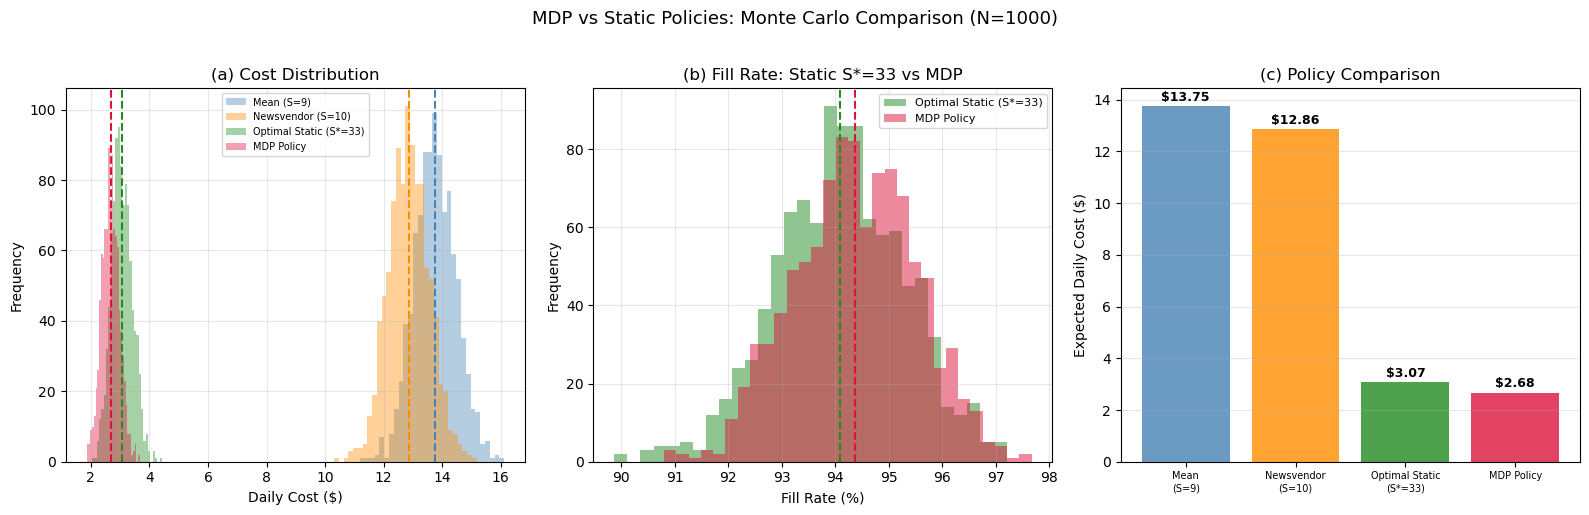

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {"Mean (S=9)": "steelblue", "Newsvendor (S=10)": "darkorange",
          "Optimal Static (S*=33)": "forestgreen", "MDP Policy": "crimson"}

# (a) Cost distribution
ax = axes[0]
for label, r in results.items():
    ax.hist(r["_cost_arr"], bins=30, alpha=0.4, label=label, color=colors[label])
    ax.axvline(r["cost"], color=colors[label], linestyle="--", linewidth=1.5)
ax.set_xlabel("Daily Cost ($)"); ax.set_ylabel("Frequency")
ax.set_title("(a) Cost Distribution"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# (b) Fill rate (S*=33 vs MDP)
ax = axes[1]
for label in ["Optimal Static (S*=33)", "MDP Policy"]:
    r = results[label]
    ax.hist(r["_fr_arr"] * 100, bins=30, alpha=0.5, label=label, color=colors[label])
    ax.axvline(r["fill_rate"] * 100, color=colors[label], linestyle="--", linewidth=1.5)
ax.set_xlabel("Fill Rate (%)"); ax.set_ylabel("Frequency")
ax.set_title("(b) Fill Rate: Static S*=33 vs MDP")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# (c) Bar comparison
ax = axes[2]
labels_list = list(results.keys())
costs_list = [results[l]["cost"] for l in labels_list]
bar_colors = [colors[l] for l in labels_list]
bars = ax.bar(range(len(labels_list)), costs_list, color=bar_colors, alpha=0.8)
ax.set_xticks(range(len(labels_list)))
ax.set_xticklabels([l.replace(" (", "\n(") for l in labels_list], fontsize=7)
ax.set_ylabel("Expected Daily Cost ($)")
ax.set_title("(c) Policy Comparison")
for bar, cost in zip(bars, costs_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"${cost:.2f}", ha="center", fontsize=9, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("MDP vs Static Policies: Monte Carlo Comparison (N=1000)", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "mdp_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

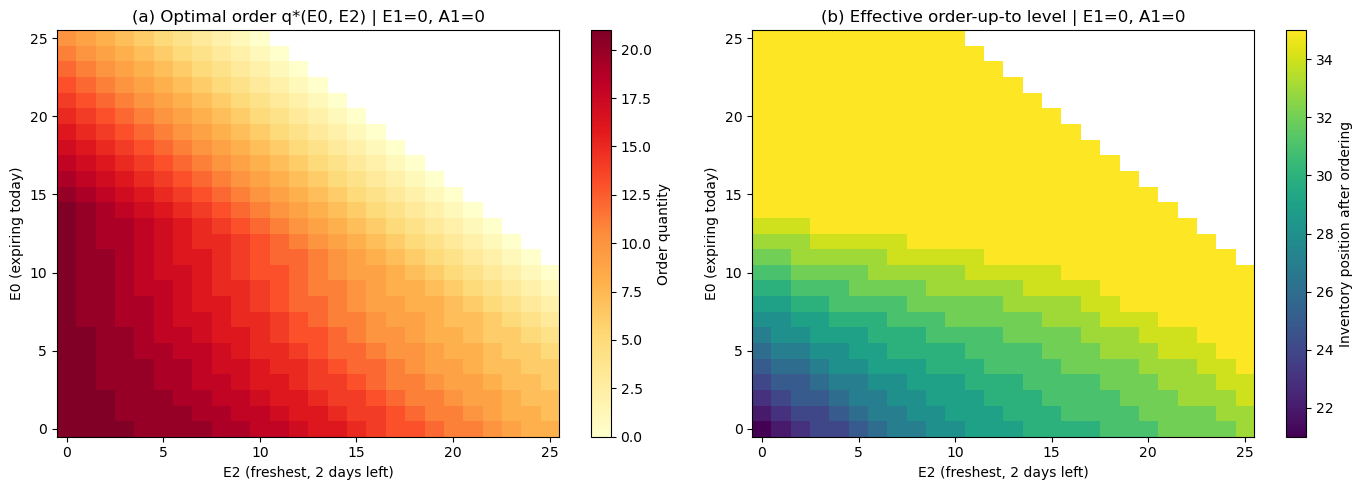

The effective S is NOT constant — higher when E0 is large (about to expire),
lower when E2 is large (fresh stock lasts). This is why MDP beats static S*=33.


In [10]:
# Policy heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

max_show = 25

# (a) Order quantity q*(E0, E2) with E1=0, A1=0
ax = axes[0]
grid = np.full((max_show + 1, max_show + 1), np.nan)
for e0 in range(max_show + 1):
    for e2 in range(max_show + 1):
        if e0 + e2 <= CAP:
            grid[e0, e2] = policy_4d[e0, 0, e2, 0]
im = ax.imshow(grid, origin="lower", cmap="YlOrRd", aspect="auto")
ax.set_xlabel("E2 (freshest, 2 days left)"); ax.set_ylabel("E0 (expiring today)")
ax.set_title("(a) Optimal order q*(E0, E2) | E1=0, A1=0")
plt.colorbar(im, ax=ax, label="Order quantity")

# (b) Effective order-up-to level
ax = axes[1]
grid_s = np.full((max_show + 1, max_show + 1), np.nan)
for e0 in range(max_show + 1):
    for e2 in range(max_show + 1):
        if e0 + e2 <= CAP:
            q = policy_4d[e0, 0, e2, 0]
            grid_s[e0, e2] = e0 + e2 + q
im = ax.imshow(grid_s, origin="lower", cmap="viridis", aspect="auto")
ax.set_xlabel("E2 (freshest, 2 days left)"); ax.set_ylabel("E0 (expiring today)")
ax.set_title("(b) Effective order-up-to level | E1=0, A1=0")
plt.colorbar(im, ax=ax, label="Inventory position after ordering")

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "mdp_policy_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

print("The effective S is NOT constant — higher when E0 is large (about to expire),")
print("lower when E2 is large (fresh stock lasts). This is why MDP beats static S*=33.")

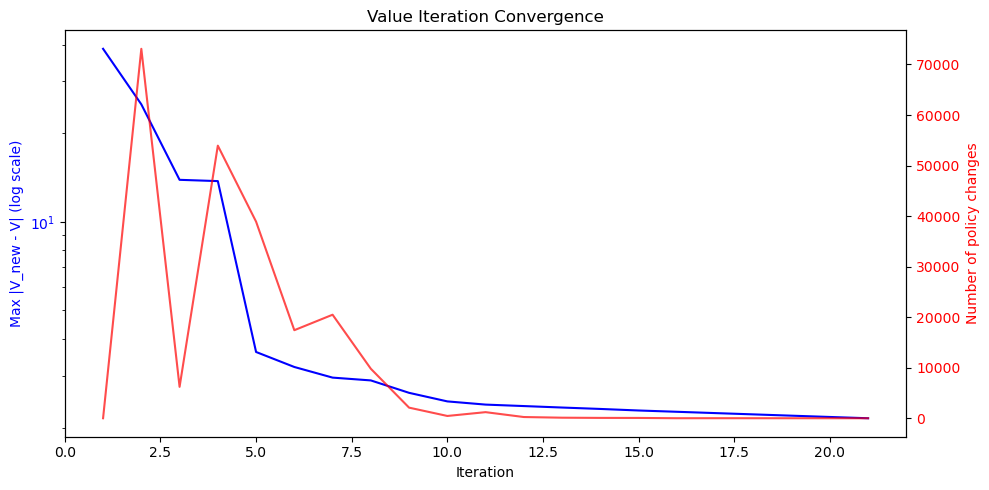

Policy converged at iteration 1
(Value function still converging but policy is stable — this is normal)


In [11]:
# Convergence plot
conv_df = pd.DataFrame(convergence_log)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.semilogy(conv_df["iter"], conv_df["max_diff"], "b-", linewidth=1.5)
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Max |V_new - V| (log scale)", color="b")
ax1.tick_params(axis="y", labelcolor="b")

ax2 = ax1.twinx()
ax2.plot(conv_df["iter"], conv_df["policy_changes"], "r-", linewidth=1.5, alpha=0.7)
ax2.set_ylabel("Number of policy changes", color="r")
ax2.tick_params(axis="y", labelcolor="r")

ax1.set_title("Value Iteration Convergence")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "mdp_convergence.png"), dpi=150)
plt.show()

if (conv_df.policy_changes == 0).any():
    ci = int(conv_df[conv_df.policy_changes == 0].iloc[0]["iter"])
    print(f"Policy converged at iteration {ci}")
    print("(Value function still converging but policy is stable — this is normal)")

## 8. Save outputs

In [12]:
comp_df.to_csv(os.path.join(TBL_DIR, "mdp_comparison.csv"), index=False)
pd.DataFrame(convergence_log).to_csv(os.path.join(TBL_DIR, "mdp_convergence.csv"), index=False)

# Save policy for select states
policy_samples = []
for e0 in range(0, min(20, CAP+1), 2):
    for e1 in range(0, min(20, CAP+1-e0), 2):
        for e2 in range(0, min(20, CAP+1-e0-e1), 5):
            for a1 in range(0, min(20, CAP+1-e0-e1-e2), 5):
                if e0+e1+e2+a1 <= CAP:
                    q = int(policy_4d[e0, e1, e2, a1])
                    policy_samples.append({
                        "E0": e0, "E1": e1, "E2": e2, "A1": a1,
                        "inv_position": e0+e1+e2+a1, "order_q": q,
                        "effective_S": e0+e1+e2+a1+q
                    })
pd.DataFrame(policy_samples).to_csv(os.path.join(TBL_DIR, "mdp_policy_samples.csv"), index=False)

print("Saved:")
for f in ["mdp_comparison.csv", "mdp_convergence.csv", "mdp_policy_samples.csv"]:
    print(f"  {TBL_DIR}/{f}")
for f in ["mdp_comparison.png", "mdp_policy_heatmap.png", "mdp_convergence.png"]:
    print(f"  {FIG_DIR}/{f}")

Saved:
  ../outputs/tables/mdp_comparison.csv
  ../outputs/tables/mdp_convergence.csv
  ../outputs/tables/mdp_policy_samples.csv
  ../outputs/figures/mdp_comparison.png
  ../outputs/figures/mdp_policy_heatmap.png
  ../outputs/figures/mdp_convergence.png


## Summary

| Policy | Cost/day | Fill Rate | Waste/day | Unmet/day |
|--------|----------|-----------|-----------|----------|
| Mean (S=9) | $13.75 | 40.2% | 0.011 | 5.49 |
| Newsvendor (S=10) | $12.86 | 44.2% | 0.015 | 5.13 |
| Optimal Static (S*=33) | $3.07 | 94.1% | 1.14 | 0.55 |
| **MDP Policy** | **$2.68** | **94.4%** | **0.92** | **0.52** |

**Key findings:**

1. The MDP achieves a **~13% cost reduction** over the best static policy at similar fill rate.

2. The savings come from **reduced waste** (0.92 vs 1.14/day) — the MDP orders less when inventory is fresh.

3. The effective order-up-to level varies from ~21 to ~35 depending on state, vs a fixed S=33.

4. The 4D state space insight (A2=0 at decision time) reduced states from 658K to 82K.

5. The MDP is like a smart store manager who checks expiration dates before ordering.